# 05 — Entry-timing counterfactuals

Replay every candidate produced by notebook 03 against multiple entry rules
(09:35, 09:45, 10:00, opening-range break, VWAP reclaim). Same stop / target /
hold geometry across all variants — only the entry timing changes. Output:
``cf_entry.parquet`` for notebook 11 to aggregate.


In [1]:
# Notebook bootstrap cell. Keep this in every bowaka_lab notebook.
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "research_notebooks").exists():
    repo_root = repo_root.parent

bowaka_project = repo_root / "research_notebooks" / "bowaka_lab"
src_path = bowaka_project / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import bowaka_lab
from bowaka_lab.utils.env import load_project_dotenv

_loaded_env = load_project_dotenv()
print(f"bowaka_lab {bowaka_lab.__version__}")
print(
    f"bowaka_lab bootstrap: .env loaded from {_loaded_env}"
    if _loaded_env
    else "bowaka_lab bootstrap: no .env found (env vars must be set in shell)"
)


bowaka_lab 0.1.0
bowaka_lab bootstrap: .env loaded from /quants-lab/.env


## Configuration

In [2]:
import os

RUN_ID                    = "bt_iex_default"
DATA_ROOT                 = os.environ.get(
    "BOWAKA_DATA_ROOT",
    "research_notebooks/bowaka_lab/db_tools/bowaka_data",
)
ARTIFACTS_ROOT            = "research_notebooks/bowaka_lab/artifacts"
FEED                      = "iex"
REBUILD                   = False

ENTRY_RULES               = [
    "fixed_time_0935",
    "fixed_time_0945",
    "fixed_time_1000",
    "opening_range_break",
    "vwap_reclaim",
]
STOP_PCT                  = 0.08
TARGET_PCT                = 0.15
MAX_HOLD_DAYS             = 3
SIGNAL_FADE_THRESHOLD     = None       # disabled — focus on entry timing
STOP_MANAGER_MODEL        = "none"
INCLUDE_REJECTED          = False     # only entered candidates


## Derived paths + config

In [3]:
from pathlib import Path

import pandas as pd

from bowaka_lab.config.models import CounterfactualConfig
from bowaka_lab.data.parquet_io import MinuteBarLoader
from bowaka_lab.sim.counterfactuals import run_grid_for_candidates
from bowaka_lab.sim.fill_model import BowakaFillModel
from bowaka_lab.utils import (
    ArtifactPaths,
    artifact_exists,
    load_parquet,
    save_parquet,
)


data_root      = Path(DATA_ROOT)      if Path(DATA_ROOT).is_absolute()      else (repo_root / DATA_ROOT).resolve()
artifacts_root = Path(ARTIFACTS_ROOT) if Path(ARTIFACTS_ROOT).is_absolute() else (repo_root / ARTIFACTS_ROOT).resolve()
MINUTE_ROOT    = data_root / "parquet/bars/vendor=alpaca" / f"feed={FEED}" / "timeframe=1m/adjustment=raw"

paths = ArtifactPaths.for_run(RUN_ID, artifacts_root)
paths.ensure_dir()
assert paths.candidates.exists(), (
    f"candidates artifact missing: {paths.candidates}\n"
    "Run notebook 03_prefilter_replay first."
)

cf_cfg = CounterfactualConfig(
    include_rejected_candidates=INCLUDE_REJECTED,
    entry_rules=ENTRY_RULES,
    stop_pct=[STOP_PCT],
    target_pct=[TARGET_PCT],
    max_hold_days=[MAX_HOLD_DAYS],
    signal_fade_thresholds=[SIGNAL_FADE_THRESHOLD],
    stop_manager_models=[STOP_MANAGER_MODEL],
)
fill_model = BowakaFillModel(slippage_bps=25.0)
minute_loader = MinuteBarLoader(MINUTE_ROOT)
print(f"artifacts:  {paths.root}")
print(f"entries:    {ENTRY_RULES}")
print(f"grid size:  {len(ENTRY_RULES)} variants per candidate")


artifacts:  /quants-lab/research_notebooks/bowaka_lab/artifacts/bt_iex_default
entries:    ['fixed_time_0935', 'fixed_time_0945', 'fixed_time_1000', 'opening_range_break', 'vwap_reclaim']
grid size:  5 variants per candidate


## Load candidates

In [4]:
candidates_df = load_parquet(paths.candidates)
print(f"candidates loaded: {candidates_df.shape[0]:,} rows over "
      f"{candidates_df['signal_date'].nunique():,} signal dates")


candidates loaded: 1,593 rows over 306 signal dates


## Build + run entry-rule grid

In [5]:
outcomes_df = None

if not REBUILD and artifact_exists(paths, "cf_entry"):
    print("Fast path: cf_entry.parquet exists; loading.")
    outcomes_df = load_parquet(paths.cf_entry)
else:
    print("Running counterfactual grid per signal date...")
    all_rows = []
    grouped = candidates_df.groupby("signal_date", sort=True)
    n_sessions = len(grouped)
    for i, (sd, group) in enumerate(grouped, start=1):
        trade_date = group["trade_date"].iloc[0]
        symbols = group["symbol"].astype(str).tolist()
        # Load minute bars once per session, keyed by symbol.
        bars_per_session = minute_loader(trade_date, symbols)
        bars_by_symbol = (
            {s: g.copy() for s, g in bars_per_session.groupby("symbol", sort=False)}
            if not bars_per_session.empty else {}
        )
        out = run_grid_for_candidates(
            candidates=group.reset_index(drop=True),
            minute_bars_by_symbol=bars_by_symbol,
            cfg=cf_cfg,
            fill_model=fill_model,
            signal_date=sd,
            trade_date=trade_date,
        )
        if not out.empty:
            all_rows.append(out)
        if i % 25 == 0:
            print(f"  {i}/{n_sessions} sessions processed")
    outcomes_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    save_parquet(paths.cf_entry, outcomes_df)
    print(f"wrote {paths.cf_entry}")

print(f"outcomes rows: {outcomes_df.shape[0]:,}")


Running counterfactual grid per signal date...
  25/306 sessions processed
  50/306 sessions processed
  75/306 sessions processed
  100/306 sessions processed
  125/306 sessions processed
  150/306 sessions processed
  175/306 sessions processed
  200/306 sessions processed
  225/306 sessions processed
  250/306 sessions processed
  275/306 sessions processed
  300/306 sessions processed
wrote /quants-lab/research_notebooks/bowaka_lab/artifacts/bt_iex_default/cf_entry.parquet
outcomes rows: 7,965


## Per-rule summary

In [6]:
if outcomes_df.empty:
    print("no counterfactual outcomes — check candidates/minute bars on disk")
else:
    # Flatten variant.entry_rule for grouping.
    df = outcomes_df.copy()
    df["entry_rule"] = df["variant"].map(
        lambda v: v.get("entry_rule") if isinstance(v, dict) else str(v).split('"entry_rule": "', 1)[-1].split('"', 1)[0]
    )
    entered = df[df["would_enter"]].copy()
    print(f"entered (would_enter=True): {entered.shape[0]:,}")

    by_rule = entered.groupby("entry_rule").agg(
        trades=("pnl_pct", "size"),
        win_rate=("pnl_pct", lambda s: float((s > 0).mean())),
        mean_pnl_pct=("pnl_pct", "mean"),
        median_pnl_pct=("pnl_pct", "median"),
    ).reset_index().sort_values("median_pnl_pct", ascending=False)
    try:
        from IPython.display import display
        display(by_rule)
    except Exception:
        print(by_rule.to_string(index=False))


entered (would_enter=True): 7,825


,entry_rule,trades,win_rate,mean_pnl_pct,median_pnl_pct
2,fixed_time_1000,1565,0.442812,-0.005526,-0.007199
3,opening_range_break,1565,0.417252,-0.007127,-0.010060
1,fixed_time_0945,1565,0.417252,-0.007127,-0.010060
4,vwap_reclaim,1565,0.417252,-0.007127,-0.010060
0,fixed_time_0935,1565,0.409585,-0.008411,-0.011816


## PnL distribution by entry rule

/tmp/ipykernel_3242/4138762981.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=ENTRY_RULES, showmeans=True)


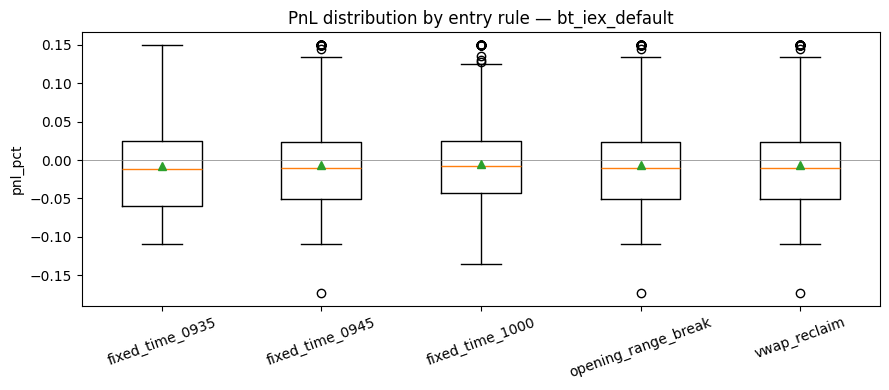

In [7]:
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

if plt is not None and not outcomes_df.empty:
    entered = outcomes_df.copy()
    entered = entered[entered["would_enter"]]
    entered["entry_rule"] = entered["variant"].map(
        lambda v: v.get("entry_rule") if isinstance(v, dict) else str(v).split('"entry_rule": "', 1)[-1].split('"', 1)[0]
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    data = [entered.loc[entered["entry_rule"] == r, "pnl_pct"].dropna().values
            for r in ENTRY_RULES]
    ax.boxplot(data, labels=ENTRY_RULES, showmeans=True)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"PnL distribution by entry rule — {RUN_ID}")
    ax.set_ylabel("pnl_pct")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    plt.show()


## Next

Open **`notebooks/06_exit_surface_and_stop_manager.ipynb`** to sweep the
stop / target / max-hold surface.